In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image


# Perceptron Trick Using Sigmoid Function

## 1. Introduction

The **Perceptron** is one of the simplest forms of a neural network, originally designed as a binary classifier. In this notebook, we explore how the perceptron learning algorithm works and how replacing the **step function** with the **sigmoid function** transforms it into a more powerful logistic regression classifier.

---

## 2. Mathematical Foundation

### 2.1 Linear Combination (Weighted Sum)

For a data point $\mathbf{x} = [x_1, x_2, ..., x_n]$ with weights $\mathbf{w} = [w_1, w_2, ..., w_n]$ and bias $b$:

$$z = \mathbf{w} \cdot \mathbf{x} + b = \sum_{i=1}^{n} w_i x_i + b$$

In matrix notation with bias included in weights:
$$z = \mathbf{W}^T \mathbf{X}$$

where $\mathbf{X} = [1, x_1, x_2, ..., x_n]$ and $\mathbf{W} = [w_0, w_1, w_2, ..., w_n]$ (with $w_0 = b$)

---

### 2.2 Activation Functions

#### Step Function (Hard Threshold)
$$\phi(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

**Properties:**
- Binary output: 0 or 1
- Non-differentiable at $z = 0$
- Abrupt decision boundary

#### Sigmoid Function (Soft Threshold)
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Properties:**
- Continuous output in range $(0, 1)$
- Differentiable everywhere
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$
- Smooth transition around decision boundary

---

## 3. Perceptron Update Rule - Complete Derivation

### 3.1 Objective
Find optimal weights $\mathbf{W}$ such that for each training sample:
$$\hat{y} = \phi(\mathbf{W}^T \mathbf{X}) \approx y$$

### 3.2 Error Calculation
For a single sample, the error is:
$$e = y - \hat{y}$$

Where:
- $y$ = actual label (0 or 1)
- $\hat{y}$ = predicted label

### 3.3 Weight Update Rule Derivation

The perceptron learning rule updates weights based on the error:

$$\mathbf{W}_{new} = \mathbf{W}_{old} + \eta \cdot (y - \hat{y}) \cdot \mathbf{X}$$

**Case Analysis:**

| Actual ($y$) | Predicted ($\hat{y}$) | Error ($y - \hat{y}$) | Update Direction |
|:---:|:---:|:---:|:---|
| 1 | 1 | 0 | No update (correct) |
| 0 | 0 | 0 | No update (correct) |
| 1 | 0 | +1 | $\mathbf{W} + \eta \mathbf{X}$ (move toward positive) |
| 0 | 1 | -1 | $\mathbf{W} - \eta \mathbf{X}$ (move toward negative) |

### 3.4 Geometric Interpretation

The decision boundary is defined by:
$$w_1 x_1 + w_2 x_2 + w_0 = 0$$

Rearranging to slope-intercept form $y = mx + c$:
$$x_2 = -\frac{w_1}{w_2} x_1 - \frac{w_0}{w_2}$$

Therefore:
- **Slope:** $m = -\frac{w_1}{w_2}$
- **Intercept:** $b = -\frac{w_0}{w_2}$

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [3]:
X

array([[ 0.82321545, -0.11697552],
       [ 0.37514771, -0.73115232],
       [ 0.26947761, -0.7081059 ],
       [-4.98744874, -2.01199214],
       [ 0.4231285 ,  1.63493163],
       [-4.2289949 ,  0.15599044],
       [-5.18865382,  1.07782053],
       [ 0.7096287 ,  0.80626713],
       [ 0.06531501,  0.74859527],
       [-5.3563263 ,  0.75152794],
       [-5.17487315, -0.90114581],
       [-5.17644221, -0.1815243 ],
       [ 0.60202649, -2.98092432],
       [ 1.42960231,  1.20500136],
       [-5.22359581,  0.78302407],
       [ 1.01127528,  0.42968688],
       [ 0.48288133, -0.73229726],
       [-5.27614308, -0.83930476],
       [ 0.44163889,  0.83727062],
       [-5.167179  , -0.10255323],
       [-5.67316396,  0.65867001],
       [-5.4617787 ,  0.92649819],
       [-4.71348919,  0.10216193],
       [ 2.2344006 ,  0.46886454],
       [-4.61308761,  0.45432938],
       [ 1.2379403 ,  1.8613386 ],
       [-5.18419324, -0.79255991],
       [-4.43807529, -1.0004391 ],
       [-5.79725951,

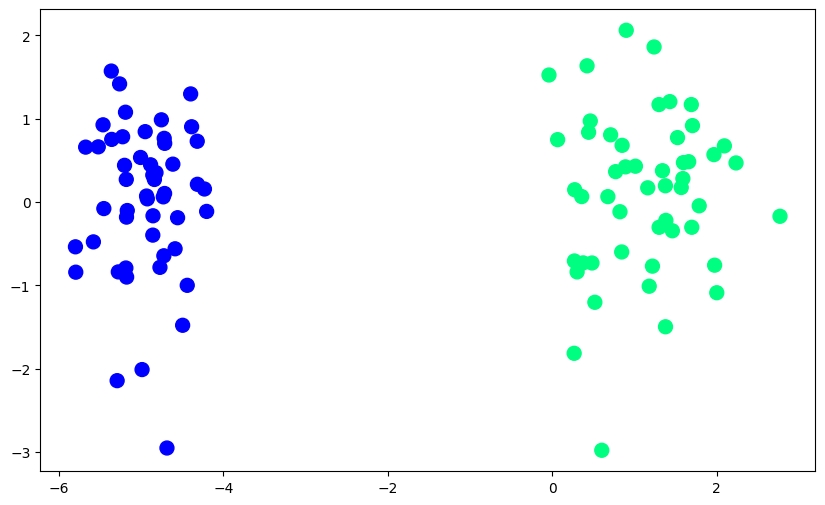

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

---

## 4. Perceptron with Step Function Implementation

### 4.1 Step Function Definition

The step function acts as a **hard threshold** activation:

$$\text{step}(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{otherwise} \end{cases}$$

**Algorithm Steps:**
1. Initialize weights $\mathbf{W} = [w_0, w_1, w_2, ...]$
2. For each epoch:
   - Select a random sample $(\mathbf{X}_j, y_j)$
   - Compute: $z = \mathbf{W}^T \mathbf{X}_j$
   - Predict: $\hat{y} = \text{step}(z)$
   - Update: $\mathbf{W} = \mathbf{W} + \eta(y_j - \hat{y})\mathbf{X}_j$
3. Return final weights

### 4.2 Perceptron Algorithm with Step Function

**Mathematical Formulation:**

Given input $\mathbf{X} = [1, x_1, x_2]$ (with bias term prepended):

1. **Linear Combination:**
$$z = w_0 \cdot 1 + w_1 \cdot x_1 + w_2 \cdot x_2 = \mathbf{W}^T\mathbf{X}$$

2. **Activation (Step Function):**
$$\hat{y} = \text{step}(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

3. **Weight Update:**
$$w_i^{(t+1)} = w_i^{(t)} + \eta \cdot (y - \hat{y}) \cdot x_i$$

Where:
- $\eta$ = learning rate (0.1 in our implementation)
- $t$ = iteration number
- $x_i$ = $i$-th feature of input (including $x_0 = 1$ for bias)

In [5]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1) # adding bias term to the data in the starting of the data [x1,x2] -> [1, x1, x2]
    weights = np.ones(X.shape[1]) # initializing the weights
    lr = 0.1 # learning rate
    
    #  Defining The Number of Epoches
    for i in range(1000): # training for 1000 iterations
        j = np.random.randint(0,100) # randomly selecting a data point
        y_hat = step(np.dot(X[j],weights)) # calculating the predicted value
        weights = weights + lr*((y[j] - y_hat)*X[j]) # updating the weights using the perceptron update rule
        
    #  returing the intercept = w0 and the weights = [w1,w2]
    return weights[0] ,weights[1:]

### 4.3 Step Function Implementation

The step function returns:
- **1** if the weighted sum $z > 0$ (classified as positive class)
- **0** if the weighted sum $z \leq 0$ (classified as negative class)

This creates a **hyperplane** that divides the feature space into two regions.

In [6]:
def step(z):
    return 1 if z>0 else 0

### 4.4 Extracting Model Parameters

After training, we obtain:
- **Intercept** ($w_0$): The bias term
- **Coefficients** ($[w_1, w_2, ...]$): Feature weights

These define our linear decision boundary.

In [7]:
intercept_coef , weights_coef = perceptron(X,y)
print("intercept coefficient : ",intercept_coef,"weights coefficient : ",weights_coef)

intercept coefficient :  1.2000000000000002 weights coefficient :  [1.1204053  0.40381514]


### 4.5 Decision Boundary Line Equation

**Derivation:**

The decision boundary is where $z = 0$:
$$w_0 + w_1 x_1 + w_2 x_2 = 0$$

Solving for $x_2$ (treating it as $y$ in 2D plot):
$$x_2 = -\frac{w_1}{w_2} x_1 - \frac{w_0}{w_2}$$

Comparing with $y = mx + b$:
- **Slope:** $m = -\frac{w_1}{w_2}$
- **Y-Intercept:** $b = -\frac{w_0}{w_2}$

In [8]:
# slop_of_line 
m = -weights_coef[0]/weights_coef[1]
print("slope of the line : ",m)
# intercept_of_line 
b = -intercept_coef/weights_coef[1]
print("intercept of the line : ",b)

slope of the line :  -2.7745500252190514
intercept of the line :  -2.9716568071029252


### 4.6 Plotting the Decision Boundary

Using the derived slope and intercept to visualize the separating hyperplane:
$$y = mx + b$$

In [9]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

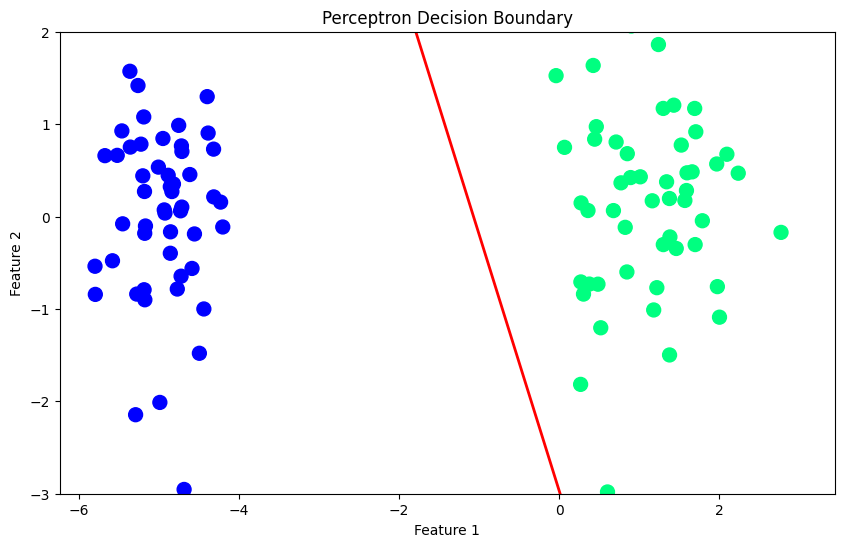

In [10]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=2)
plt.scatter(X[:,0],X[:,1],c=y,cmap="winter",s=100)
plt.ylim(-3,2)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perceptron Decision Boundary")
plt.show()

---

## 4.7 Comparison: Sklearn's Logistic Regression

Sklearn's `LogisticRegression` uses:
- **Optimization:** L-BFGS, Newton-CG, or SGD solvers
- **Loss Function:** Cross-entropy (Log-loss)
$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$$
- **Regularization:** L2 penalty (default) with $C = 1.0$

This provides a more robust and optimized solution compared to our simple perceptron.

In [11]:
from sklearn.linear_model import LogisticRegression
logistic_regression_using_inbuilt_function = LogisticRegression()
logistic_regression_using_inbuilt_function.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 4.8 Sklearn Model Coefficients

Extracting learned parameters from the trained sklearn model:

In [12]:
logistic_regression_using_inbuilt_function_coef = logistic_regression_using_inbuilt_function.coef_
logistic_regression_using_inbuilt_function_intercept = logistic_regression_using_inbuilt_function.intercept_
print("intercept coefficient : ",logistic_regression_using_inbuilt_function_intercept,"weights coefficient : ",logistic_regression_using_inbuilt_function_coef)

intercept coefficient :  [3.54700273] weights coefficient :  [[1.77255101 0.01190507]]


### 4.9 Sklearn Decision Boundary

Computing the decision boundary from sklearn's coefficients:

**Slope and Intercept from Sklearn:**
$$m = -\frac{\text{coef}[0][0]}{\text{coef}[0][1]}, \quad b = -\frac{\text{intercept}}{\text{coef}[0][1]}$$

In [13]:
m_logistic_inbuilt = -logistic_regression_using_inbuilt_function_coef[0][0]/logistic_regression_using_inbuilt_function_coef[0][1]
b_logistic_inbuilt = -logistic_regression_using_inbuilt_function_intercept/logistic_regression_using_inbuilt_function_coef[0][1]

### 4.10 Sklearn Decision Boundary Visualization

Generating points along the sklearn decision boundary line:

In [14]:
x_input_logistic_inbuilt = np.linspace(-3,3,100)
y_input_logistic_inbuilt = m_logistic_inbuilt*x_input_logistic_inbuilt + b_logistic_inbuilt

(-3.0, 2.0)

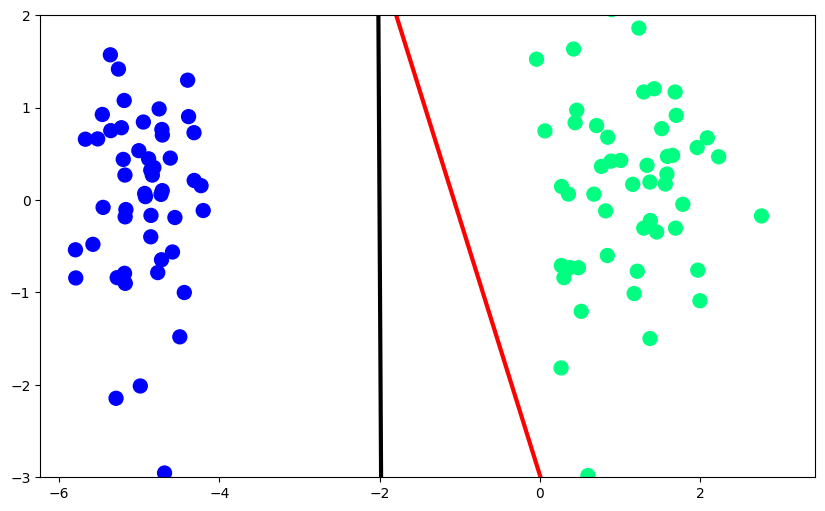

In [15]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input_logistic_inbuilt,y_input_logistic_inbuilt,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

---

## 5. Perceptron with Sigmoid Function (Logistic Regression)

### 5.1 Why Replace Step with Sigmoid?

| Aspect | Step Function | Sigmoid Function |
|:---|:---:|:---:|
| Output Range | {0, 1} | (0, 1) |
| Differentiability | Not differentiable at 0 | Smooth, differentiable everywhere |
| Gradient-based Learning | Not suitable | Ideal for gradient descent |
| Probabilistic Interpretation | None | Represents probability |

### 5.2 Sigmoid Function Derivation

The sigmoid function is derived from the **logistic function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Derivative of Sigmoid (Important for Backpropagation):**

Let $\sigma(z) = \frac{1}{1 + e^{-z}} = (1 + e^{-z})^{-1}$

Using chain rule:
$$\frac{d\sigma}{dz} = -1 \cdot (1 + e^{-z})^{-2} \cdot (-e^{-z})$$

$$= \frac{e^{-z}}{(1 + e^{-z})^2}$$

$$= \frac{1}{1 + e^{-z}} \cdot \frac{e^{-z}}{1 + e^{-z}}$$

$$= \sigma(z) \cdot \frac{(1 + e^{-z}) - 1}{1 + e^{-z}}$$

$$= \sigma(z) \cdot (1 - \sigma(z))$$

**Final Result:**
$$\boxed{\sigma'(z) = \sigma(z)(1 - \sigma(z))}$$

### 5.3 Modified Perceptron Update Rule with Sigmoid

The update rule remains structurally similar but uses sigmoid activation:

$$\hat{y} = \sigma(\mathbf{W}^T\mathbf{X}) = \frac{1}{1 + e^{-\mathbf{W}^T\mathbf{X}}}$$

$$\mathbf{W}_{new} = \mathbf{W}_{old} + \eta \cdot (y - \hat{y}) \cdot \mathbf{X}$$

**Key Difference:** 
- With step function: $\hat{y} \in \{0, 1\}$ → $(y - \hat{y}) \in \{-1, 0, 1\}$
- With sigmoid: $\hat{y} \in (0, 1)$ → $(y - \hat{y}) \in (-1, 1)$ (continuous)

This allows for **smoother weight updates** and better convergence!

### 5.4 Perceptron Algorithm with Sigmoid Function

**Algorithm:**
```
Input: X (features), y (labels), η (learning rate), epochs
Output: Trained weights W

1. X ← prepend column of 1s to X (for bias)
2. W ← initialize to ones
3. For i = 1 to epochs:
   a. j ← random sample index
   b. z ← W · X[j]
   c. ŷ ← σ(z) = 1/(1 + e^(-z))
   d. W ← W + η(y[j] - ŷ)X[j]
4. Return W[0] (intercept), W[1:] (coefficients)
```

In [16]:
def perceptron_custom_sigmoid(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [17]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [18]:
intercept_coef_custom_sigmoid ,weights_coef_custom_sigmoid = perceptron_custom_sigmoid(X,y)
print("intercept coefficient using custom sigmoid : ",intercept_coef_custom_sigmoid,"weights coefficient with Custom Sigmoid function : ",weights_coef_custom_sigmoid)

intercept coefficient using custom sigmoid :  2.593325875973906 weights coefficient with Custom Sigmoid function :  [2.31472154 0.2188512 ]


In [19]:
m_custom_sigmoid = -weights_coef_custom_sigmoid[0]/weights_coef_custom_sigmoid[1]
b_custom_sigmoid = -intercept_coef_custom_sigmoid/weights_coef_custom_sigmoid[1]

In [20]:
X_input_custom_sigmoid = np.linspace(-3,3,100)
y_input_custom_sigmoid = m_custom_sigmoid*X_input_custom_sigmoid + b_custom_sigmoid

(-3.0, 2.0)

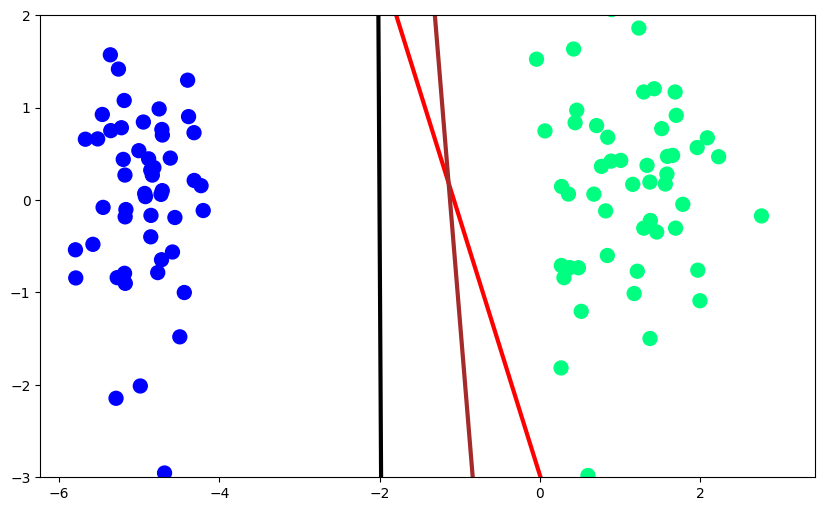

In [21]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input_logistic_inbuilt,y_input_logistic_inbuilt,color='black',linewidth=3)
plt.plot(X_input_custom_sigmoid,y_input_custom_sigmoid,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

---

## 5.5 Visualizing Learning Progress (Animation)

The animation below demonstrates how the **decision boundary evolves** during training. Each frame represents one epoch where:
1. A random sample is selected
2. The error is computed
3. Weights are updated
4. The decision boundary shifts

**Observation:** Notice how the boundary converges to a stable position that separates the two classes!

In [22]:
def perceptron_animation_through_epoches(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [23]:
m,b = perceptron_animation_through_epoches(X,y)

In [24]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

<IPython.core.display.Javascript object>

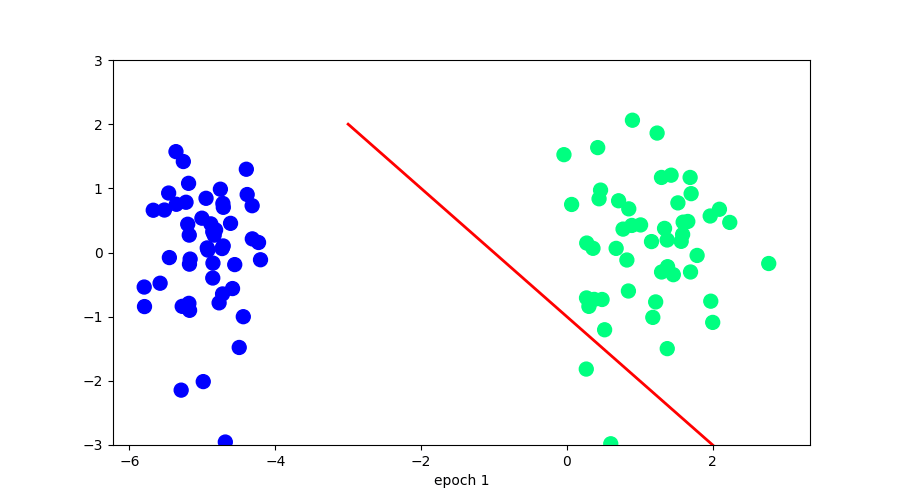

In [25]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
anim.save("Preceptron Logistic Regression using Sigmoid.gif", writer=animation.PillowWriter(fps=10))
display(Image("Preceptron Logistic Regression using Sigmoid.gif"))

---

## 6. Comprehensive Summary

### 6.1 Comparison Table: Step vs Sigmoid Activation

| **Aspect** | **Perceptron (Step Function)** | **Perceptron (Sigmoid Function)** | **Sklearn Logistic Regression** |
|:---|:---:|:---:|:---:|
| **Activation Function** | $\phi(z) = \begin{cases} 1, z>0 \\ 0, z\leq0 \end{cases}$ | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| **Output Range** | {0, 1} discrete | (0, 1) continuous | (0, 1) continuous |
| **Differentiable** | ❌ No (at z=0) | ✅ Yes | ✅ Yes |
| **Update Magnitude** | Fixed (±η) | Variable (proportional to error) | Gradient-based (optimized) |
| **Convergence** | Guaranteed (linearly separable) | Smoother, may overshoot | L-BFGS/SGD optimized |
| **Probabilistic Output** | ❌ No | ✅ Yes (probability) | ✅ Yes (probability) |
| **Loss Function** | Perceptron criterion | Not explicitly defined | Log-loss (Cross-entropy) |
| **Regularization** | ❌ None | ❌ None | ✅ L2 (default C=1.0) |

### 6.2 Key Formulas Summary

| **Formula** | **Expression** | **Description** |
|:---|:---:|:---|
| Linear Combination | $z = \mathbf{W}^T\mathbf{X} = \sum_{i=0}^{n} w_i x_i$ | Weighted sum of inputs |
| Step Function | $\phi(z) = \mathbb{1}_{z>0}$ | Binary threshold activation |
| Sigmoid Function | $\sigma(z) = \frac{1}{1+e^{-z}}$ | Smooth activation |
| Sigmoid Derivative | $\sigma'(z) = \sigma(z)(1-\sigma(z))$ | Used in gradient computation |
| Perceptron Update | $\mathbf{W} \leftarrow \mathbf{W} + \eta(y-\hat{y})\mathbf{X}$ | Weight adjustment rule |
| Decision Boundary Slope | $m = -\frac{w_1}{w_2}$ | From $w_1x_1 + w_2x_2 + w_0 = 0$ |
| Decision Boundary Intercept | $b = -\frac{w_0}{w_2}$ | Y-axis intercept |

### 6.3 Algorithm Complexity

| **Metric** | **Value** |
|:---|:---:|
| Time Complexity (per epoch) | $O(n)$ where n = number of features |
| Space Complexity | $O(n)$ for weights |
| Convergence | Stochastic (random sample selection) |

### 6.4 Key Takeaways

1. **Step Function** creates a hard decision boundary - suitable for simple linearly separable data
2. **Sigmoid Function** provides probability estimates and smoother weight updates
3. **Sklearn's LogisticRegression** uses optimized solvers and regularization for better generalization
4. The **decision boundary equation** $w_1x_1 + w_2x_2 + w_0 = 0$ separates the two classes
5. All three methods converge to similar decision boundaries for well-separated data

---

### 6.5 References

- Rosenblatt, F. (1958). "The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain"
- Bishop, C.M. (2006). "Pattern Recognition and Machine Learning" - Chapter 4
- Murphy, K.P. (2012). "Machine Learning: A Probabilistic Perspective" - Chapter 8